### NOTICE
#### Below code is just for ensuring the versions used by the SpaceDebrisRadar virtual enviornment.

In [1]:
import sys
import importlib

libs = ["pandas", "streamlit", "matplotlib", "seaborn", "sklearn", 'numpy', 'sklearn', 'scipy']

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print("-" * 70)

for lib in libs:
    try:
        module = importlib.import_module(lib)
        print(f"{lib} version: {module.__version__}")
        print(f"{lib} path: {module.__file__}")
    except ModuleNotFoundError:
        print(f"{lib} is NOT installed in this environment.")
    print("-" * 70)


Python executable: C:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\python.exe
Python version: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]
----------------------------------------------------------------------
pandas version: 2.3.1
pandas path: C:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\pandas\__init__.py
----------------------------------------------------------------------
streamlit version: 1.48.0
streamlit path: C:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\streamlit\__init__.py
----------------------------------------------------------------------
matplotlib version: 3.10.0
matplotlib path: C:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\matplotlib\__init__.py
----------------------------------------------------------------------
seaborn version: 0.13.2
seaborn path: C:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\seaborn\__init__.py
---------------------------

In [2]:
# IMPORT HERE!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Important thorughout this project
%matplotlib inline


In [3]:
#df = pd.read_csv('https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=csv', low_memory=False)
df = pd.read_csv('../data/raw/gp.csv')

### 📑 Useful Columns for SpaceDebrisRadar.AI

| Column Name     | Description                           | Usage in Project (ML/Logic) |
|-----------------|---------------------------------------|------------------------------|
| NORAD_CAT_ID    | Unique satellite identifier           | Tracking & referencing       |
| OBJECT_NAME     | Satellite/system name                 | System-based queries (e.g., Starlink) |
| MEAN_MOTION     | Revolutions per day (orbit speed)     | Clustering (KMeans), anomaly trends |
| INCLINATION     | Orbital tilt in degrees               | Clustering (shell grouping)  |
| ECCENTRICITY    | Orbit shape (circular vs. elliptical) | Orbit stability, anomaly detection |
| BSTAR           | Drag coefficient proxy                | Anomaly detection (decay risk) |
| EPOCH           | Timestamp of orbital elements         | Time-series, forecasting     |

----
### 🔎 About OBJECT_ID (A, B, C parts)

- `OBJECT_ID` format → `YYYY-NNNP`  
  - `YYYY` → Launch year  
  - `NNN` → Launch number in that year  
  - `P` → Piece (A, B, C, …)

- `A` → Primary payload (main satellite)  
- `B, C, …` → Secondary payloads, rocket bodies, or debris  
- Each part is a **separate object** in orbit (they do not join back).  
- Useful for anomaly detection → older `B/C` objects are often unstable or decaying.


In [4]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2025-07-31T20:36:40.080672,13.761315,0.002491,90.2131,64.4033,177.3590,245.8673,0,U,900,999,2736,0.000547,5.420000e-06,0.0
1,CALSPHERE 2,1964-063E,2025-07-31T15:15:32.855616,13.528676,0.002053,90.2271,68.2736,79.0754,343.8107,0,U,902,999,81292,0.000050,4.200000e-07,0.0
2,LCS 1,1965-034C,2025-07-31T23:18:14.440608,9.893093,0.001279,32.1358,217.3352,68.2023,291.9834,0,U,1361,999,17817,0.001208,1.800000e-07,0.0
3,TEMPSAT 1,1965-065E,2025-07-31T23:25:04.298016,13.335684,0.007153,89.9758,212.8402,68.5165,309.8791,0,U,1512,999,91737,0.000054,3.600000e-07,0.0
4,CALSPHERE 4A,1965-065H,2025-07-31T19:27:37.344960,13.362074,0.006773,89.9219,125.3726,288.8275,133.5130,0,U,1520,999,91992,0.000158,9.000000e-07,0.0


In [5]:
df.shape

(12291, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12291 entries, 0 to 12290
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OBJECT_NAME          12291 non-null  object 
 1   OBJECT_ID            12291 non-null  object 
 2   EPOCH                12291 non-null  object 
 3   MEAN_MOTION          12291 non-null  float64
 4   ECCENTRICITY         12291 non-null  float64
 5   INCLINATION          12291 non-null  float64
 6   RA_OF_ASC_NODE       12291 non-null  float64
 7   ARG_OF_PERICENTER    12291 non-null  float64
 8   MEAN_ANOMALY         12291 non-null  float64
 9   EPHEMERIS_TYPE       12291 non-null  int64  
 10  CLASSIFICATION_TYPE  12291 non-null  object 
 11  NORAD_CAT_ID         12291 non-null  int64  
 12  ELEMENT_SET_NO       12291 non-null  int64  
 13  REV_AT_EPOCH         12291 non-null  int64  
 14  BSTAR                12291 non-null  float64
 15  MEAN_MOTION_DOT      12291 non-null 

In [7]:
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
count,12291.000000,12291.000000,12291.000000,12291.000000,12291.000000,12291.000000,12291.0,12291.000000,12291.0,12291.000000,12291.000000,12291.000000,1.229100e+04
mean,14.116961,0.003084,59.099606,184.244779,161.087567,197.592263,0.0,54817.586039,999.0,13155.206086,-0.000333,-0.000024,3.561276e-06
std,3.435129,0.042024,24.149973,108.475330,95.161719,95.351289,0.0,8245.749407,0.0,13178.379452,0.009535,0.002346,5.111107e-05
min,0.077615,0.000004,0.001600,0.039000,0.013000,0.047300,0.0,900.000000,999.0,8.000000,-0.337070,-0.048918,-6.069300e-07
25%,14.985308,0.000121,43.003400,84.721350,85.355050,93.376250,0.0,49767.500000,999.0,4131.500000,0.000000,-0.000002,0.000000e+00
50%,15.088371,0.000148,53.159700,188.984300,105.402800,249.826100,0.0,56874.000000,999.0,10369.000000,0.000046,0.000003,0.000000e+00
75%,15.293483,0.000318,81.004950,286.442450,266.961300,274.337800,0.0,61060.500000,999.0,17781.000000,0.000396,0.000080,0.000000e+00
max,16.398516,0.909992,150.081800,359.977300,359.843500,359.906300,0.0,65055.000000,999.0,99807.000000,0.117360,0.083195,1.890100e-03


In [8]:
df['OBJECT_NAME']

0                CALSPHERE 1
1                CALSPHERE 2
2                      LCS 1
3                  TEMPSAT 1
4               CALSPHERE 4A
                ...         
12286    HULIANWANG DIGUI 6G
12287    HULIANWANG DIGUI 6H
12288    HULIANWANG DIGUI 6J
12289                  NISAR
12290                 PRSS-1
Name: OBJECT_NAME, Length: 12291, dtype: object

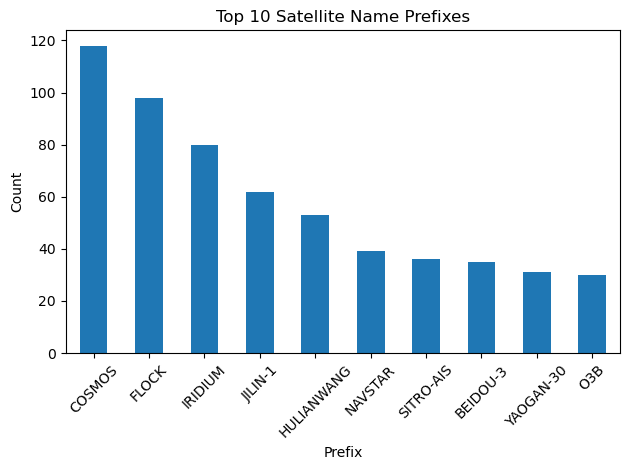

In [9]:
df['OBJECT_NAME'].str.split().str[0].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Satellite Name Prefixes')
plt.xlabel('Prefix')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()



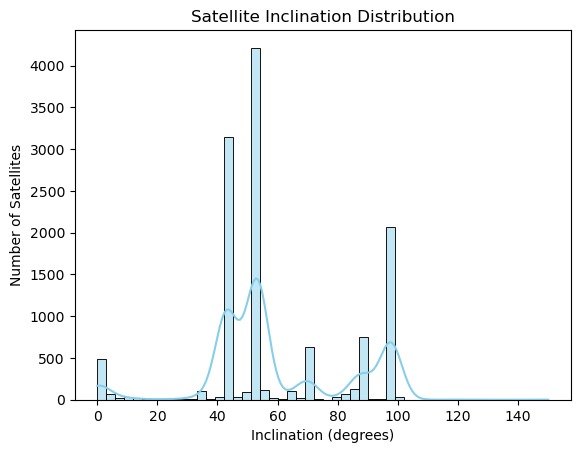

In [24]:
sns.histplot(data=df, x = 'INCLINATION', bins=50, color='skyblue', kde = True)

plt.title('Satellite Inclination Distribution')
plt.xlabel('Inclination (degrees)')
plt.ylabel('Number of Satellites')
plt.show()


(0.0, 0.05)

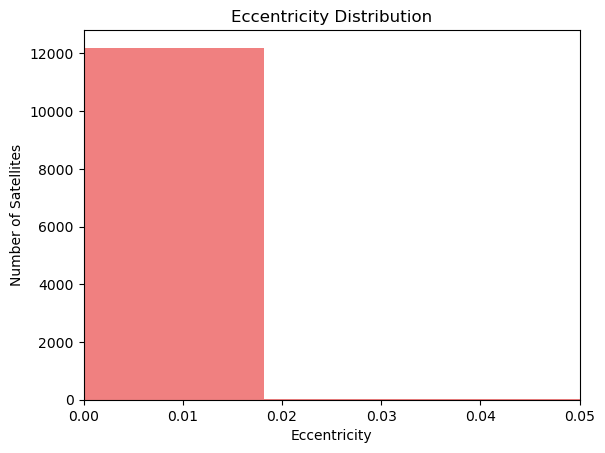

In [11]:
df['ECCENTRICITY'].plot(kind='hist', bins=50, color='lightcoral')
plt.title('Eccentricity Distribution')
plt.xlabel('Eccentricity')
plt.ylabel('Number of Satellites')

plt.xlim(0, 0.05)

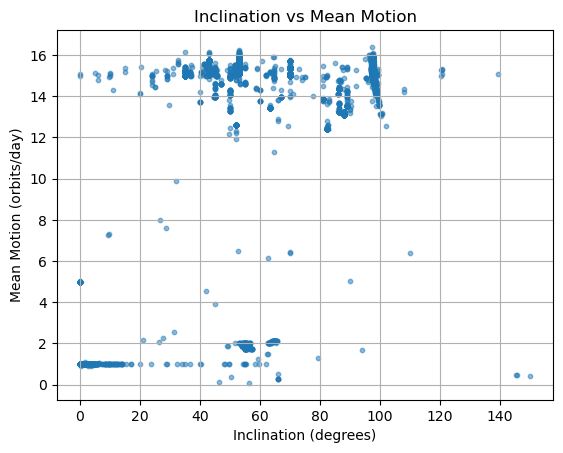

In [12]:
plt.scatter(df['INCLINATION'], df['MEAN_MOTION'], alpha=0.5, s=10)
plt.title('Inclination vs Mean Motion')
plt.xlabel('Inclination (degrees)')
plt.ylabel('Mean Motion (orbits/day)')
plt.grid(True)
plt.show()


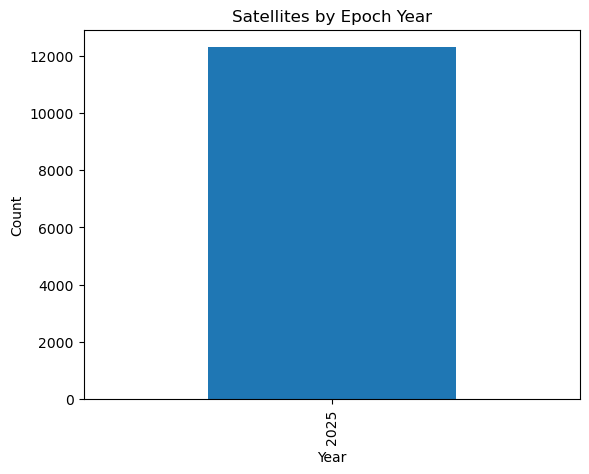

In [13]:
df['EPOCH'] = pd.to_datetime(df['EPOCH'], errors='coerce')
df['EPOCH'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title('Satellites by Epoch Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


In [14]:
df.tail()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
12286,HULIANWANG DIGUI 6G,2025-162G,2025-07-31 10:29:37.194720,14.065991,0.000705,50.0092,10.6925,286.7731,74.9386,0,U,65049,999,15,0.000000,-1.530000e-06,0.0
12287,HULIANWANG DIGUI 6H,2025-162H,2025-07-30 21:25:11.582688,14.067159,0.000749,50.0065,12.9147,278.6827,202.9834,0,U,65050,999,8,0.000000,-1.530000e-06,0.0
12288,HULIANWANG DIGUI 6J,2025-162J,2025-08-01 12:03:40.061664,14.066874,0.000688,50.0013,6.3389,280.2536,80.3344,0,U,65051,999,31,0.000100,1.400000e-07,0.0
12289,NISAR,2025-163A,2025-08-01 05:04:48.916992,14.458823,0.001224,98.4437,40.0798,266.1208,93.8584,0,U,65053,999,24,0.000095,2.930000e-06,0.0
12290,PRSS-1,2025-164A,2025-08-01 13:08:12.057792,15.052632,0.000658,41.1316,289.8754,244.7083,262.3118,0,U,65055,999,19,0.000000,-1.780000e-06,0.0


In [15]:
df[df['OBJECT_NAME'].str.contains('STARLINK')]

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
1388,STARLINK-1008,2019-074B,2025-07-31 23:15:03.751488,15.063970,0.000128,53.0545,97.4753,82.3855,277.7279,0,U,44714,999,31548,0.000205,0.000028,0.000000
1389,STARLINK-1010,2019-074D,2025-07-31 22:00:01.999584,15.632013,0.000311,53.0537,70.4140,203.3956,46.1290,0,U,44716,999,592,0.001297,0.001221,0.000000
1390,STARLINK-1011,2019-074E,2025-08-01 06:00:02.000160,15.150157,0.000180,53.0538,116.0772,85.1009,41.6479,0,U,44717,999,31541,0.085747,0.017802,0.000000
1391,STARLINK-1012,2019-074F,2025-07-31 22:43:13.415520,15.063896,0.000127,53.0554,97.5754,91.6389,268.4745,0,U,44718,999,31547,0.000063,0.000007,0.000000
1392,STARLINK-1013,2019-074G,2025-07-31 22:00:01.999584,15.902881,0.000307,53.0451,57.1923,112.9440,277.0899,0,U,44719,999,31620,0.000977,0.003008,0.000044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12269,STARLINK-34738,2025-158V,2025-07-31 22:00:01.999584,15.926994,0.000123,97.5997,73.9243,107.7445,215.8374,0,U,64951,999,191,-0.005538,-0.018733,0.000971
12270,STARLINK-34744,2025-158W,2025-07-31 22:00:01.999584,15.928884,0.000124,97.5998,73.9258,102.4144,223.9594,0,U,64952,999,191,-0.005568,-0.019017,0.001001
12271,STARLINK-34701,2025-158X,2025-07-31 22:00:01.999584,15.927910,0.000125,97.5999,73.9254,103.6328,221.2943,0,U,64953,999,191,-0.005542,-0.018837,0.000982
12272,STARLINK-34761,2025-158Y,2025-07-31 22:00:01.999584,15.929883,0.000121,97.6000,73.9265,102.4961,225.3751,0,U,64954,999,191,-0.005591,-0.019192,0.001019


Text(0.5, 0, 'Mean Motion')

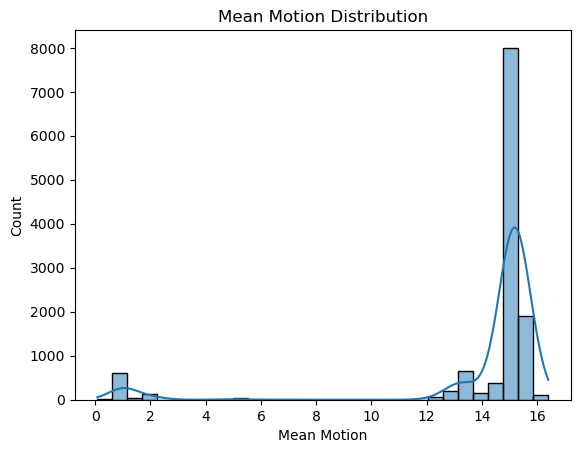

In [16]:
sns.histplot(data=df, x = 'MEAN_MOTION', bins = 30, kde=True)

plt.title('Mean Motion Distribution')
plt.xlabel('Mean Motion')


In [26]:
df['BSTAR'].value_counts()

BSTAR
 0.000000    804
 0.000214      5
 0.000334      4
 0.000131      3
 0.000020      3
            ... 
-0.005365      1
-0.005397      1
-0.005417      1
-0.005446      1
 0.000040      1
Name: count, Length: 11197, dtype: int64

(-0.2, 0.2)

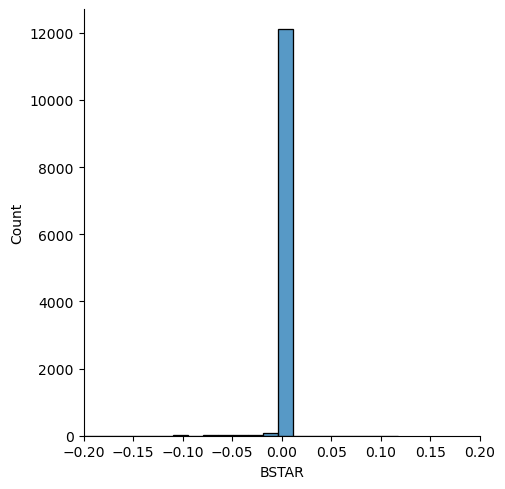

In [34]:
sns.displot(data=df, x = 'BSTAR', bins = 30)

plt.xlim(-0.2, 0.2)
#plt.ylim(-0.1, 2)

Text(0.5, 0, 'Revolutions')

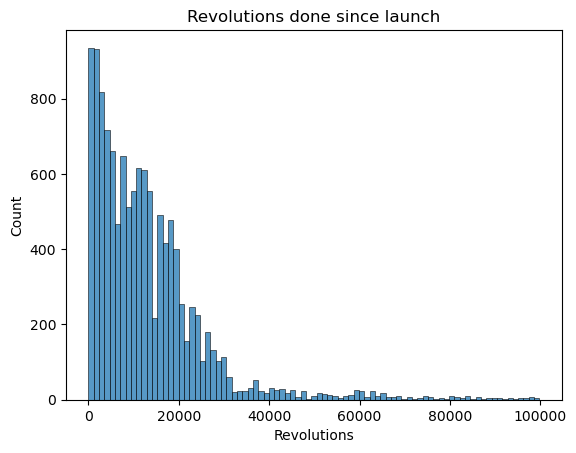

In [19]:
sns.histplot(data=df, x = 'REV_AT_EPOCH')

plt.title('Revolutions done since launch')
plt.xlabel('Revolutions')

In [20]:
# Compare total orbits done and the launch year distribution
launch_years = df['OBJECT_ID'].str.strip().str.split('-').str[0]

In [21]:
launch_years

0        1964
1        1964
2        1965
3        1965
4        1965
         ... 
12286    2025
12287    2025
12288    2025
12289    2025
12290    2025
Name: OBJECT_ID, Length: 12291, dtype: object

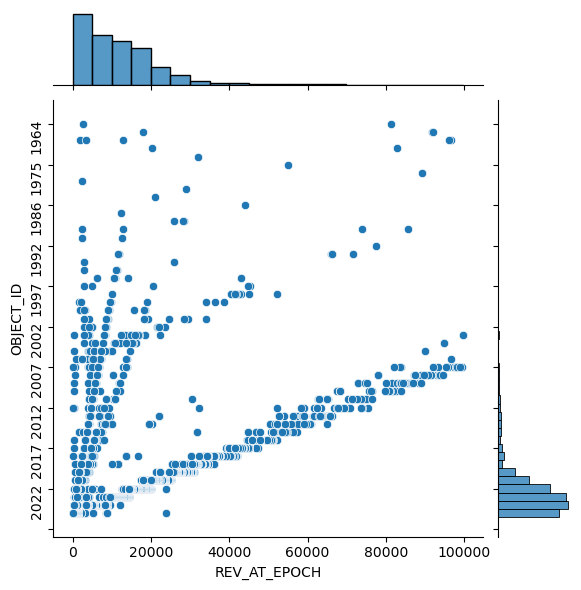

In [35]:
import matplotlib.ticker as ticker
g = sns.jointplot(data=df, x='REV_AT_EPOCH', y=launch_years, kind='scatter', marginal_kws=dict(bins=20, orientation="vertical"))

# Set a major tick for every 5 years on the y-axis
g.ax_joint.yaxis.set_major_locator(ticker.MultipleLocator(5))
g.ax_joint.tick_params(axis='y', rotation=90)

plt.show()